# Does the oldest momentum tool actually beat just holding? ⏱️
### Rate of Change (ROC) — the granddaddy of momentum indicators, on the bench

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Better_momentum_tool%3F: Misattributed](https://img.shields.io/badge/Better_momentum_tool%3F-Misattributed-8b949e?style=flat-square)

Open any trading book and you'll meet **Rate of Change** early. It's almost embarrassingly simple: take today's price, compare it to the price *N* days ago, and express the gap as a percent. ROC above zero means "price is higher than it was" — an uptrend. The folk rule: **go long when ROC is positive, step aside to cash when it goes negative.** Ride the trend, dodge the crashes.

It *sounds* like free risk management. And here's the twist this study uncovers: the rule really does cut your worst drawdown roughly in **half** — but it does it by **giving up return**, and once you line it up against the dead-simplest alternative (a 200-day moving average) it's a **photo finish**. The "oldest momentum tool" turns out to be one of *many* trend filters, none special.

> 📓 **Plain-language layer.** Want the *t*-stats, the permutation test and the cost math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Data note.** SPY daily **total-return** closes (dividends + splits folded in), 1993→2026, pinned to the last complete month. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from rate_of_change import data, strategy as st

HAVE_REAL = data.have_real("SPY")
if HAVE_REAL:
    BARS = data.load_real("SPY").loc[:"2026-05-31"]   # pinned to the last complete month
    CLOSE = BARS["close"]
else:
    BARS = CLOSE = None
print("real SPY cache present:", HAVE_REAL,
      "| bars:", (0 if BARS is None else len(BARS)))

# frozen headline numbers (mirror of docs/results.md)
R = {'ticker': 'SPY', 'start': '1993-01-29', 'end': '2026-05-29', 'n_bars': 8390, 'years': 32.8, 'fingerprint': 'f3fa058adfc8', 'window': 126, 'cost_bps': 1.0, 'rf_annual': 0.02, 'roc': {'sharpe': 0.591, 'cagr': 0.0881, 'maxdd': -0.314, 't_exc': 3.71, 'turnover': 6.6, 'exposure': 0.76}, 'hold': {'sharpe': 0.542, 'cagr': 0.109, 'maxdd': -0.552, 't_exc': 3.64}, 'diff': {'delta_ann': -0.0297, 't_diff': -1.47}, 'placebo': {'obs': 0.591, 'p': 0.034}, 'breakeven_bps': 0.0, 'ls': {'sharpe': 0.225, 'cagr': 0.0456, 'maxdd': -0.465, 'delta_ann': -0.0594, 't_diff': -1.47}, 'race': [('Buy & hold', 0.542, 0.109, -0.552, 3.64, 0.0), ('ROC(126)', 0.591, 0.0881, -0.314, 3.71, 6.6), ('SMA(200)', 0.58, 0.0865, -0.283, 3.55, 6.6), ('MACD(12,26,9)', 0.244, 0.0416, -0.385, 1.52, 21.4), ('RSI(14)>50', 0.28, 0.0458, -0.445, 1.67, 26.7)], 'windows': [(21, 0.264, 0.0441, -0.071, -3.28), (63, 0.456, 0.0679, -0.0491, -2.29), (126, 0.591, 0.0881, -0.0297, -1.47), (252, 0.61, 0.0998, -0.0162, -0.87)], 'costs': [(0.0, 0.596, 0.0888), (1.0, 0.591, 0.0881), (2.0, 0.586, 0.0873), (5.0, 0.569, 0.0852), (10.0, 0.542, 0.0816)], 'syn': [(0.0, -0.29, -0.11, -0.0128, -0.57), (0.5, 4.83, -0.15, 0.7602, 11.01)]}


real SPY cache present: True | bars: 8390


## The answer first

| Question | Answer |
|---|---|
| Does ROC timing make money? | **Yes — but so does just holding.** ROC's Sharpe (**0.59**) edges out buy-and-hold's (**0.54**), but its **return is lower** (8.8%/yr vs 10.9%/yr). |
| Does it *add* anything over holding? | **No, not measurably.** ROC minus buy-and-hold is **−3.0%/yr** with *t* = **−1.47** — a small, statistically-insignificant *loss* of return. |
| So what's it good for? | **Cutting the drawdown.** Worst loss drops from **−55%** (hold) to **−31%** (ROC). It's a risk-reducer, not an alpha source. |
| Is it a *better* momentum tool? | **No.** A plain **200-day moving-average** cross ties it almost exactly (Sharpe 0.58 vs 0.59). ROC isn't special — it's one trend filter among many. |

> The oldest momentum tool *works* in the narrow sense that staying long during uptrends is sensible — but it earns that calm by **leaving return on the table**, and nothing about the ROC formula beats the simplest moving average.

## 1 · The claim

> *"Rate of Change is the purest momentum indicator there is. When ROC crosses above zero the trend is up — buy. When it crosses below, the trend is down — get out. You ride the big moves and sidestep the crashes."*

ROC has been in the technician's toolbox since the **1970s** (it predates RSI and MACD), and every charting platform ships it. The steelman is real: momentum *is* one of the best-documented anomalies in finance (Jegadeesh & Titman 1993). So the question isn't "is momentum a thing?" — it's **"does this 50-year-old one-line formula capture it any better than holding, or than the next indicator over?"**

## 2 · So what?

If a one-line indicator could reliably beat buy-and-hold *after costs*, it would be the best deal in finance — free outperformance from arithmetic you can do in your head. That's a big claim, so it deserves a hard test.

Two traps hide here. **(1) Beta in disguise.** A long/flat rule that's invested ~75% of the time will look great in a 30-year bull market — but that's mostly just *owning stocks*, not the indicator's skill. The honest test is ROC **minus** buy-and-hold. **(2) Indicator vanity.** Every momentum filter — ROC, a moving-average cross, MACD — is secretly the same bet ("stay long while price rises"). If they all tie, the *specific* indicator is a distraction. We test both.

## 3 · How would we even know?

We compute **ROC over 126 trading days** on **33 years** of SPY (1993-01-29 → 2026-05-29). Then:

1. **The rule.** Long when ROC > 0, flat (cash) otherwise. The signal is read at today's close; the position earns **tomorrow's** return (one-day lag, no cheating).
2. **The race.** Compare its risk-adjusted return (Sharpe), its growth (CAGR) and its worst drawdown against simply **buying and holding** SPY — and against a **200-day moving average**, **MACD**, and **RSI**, so "ROC is better" is actually checked.
3. **The verdict line.** If ROC's edge **over buy-and-hold** isn't clearly positive after costs, the timing adds nothing — it's just dialing your stock exposure up and down.

## 4 · The teardown — let's actually look

**First, the headline race.** Here's the growth of $1 in SPY held forever vs the same dollar run through the ROC long/flat rule (net of a realistic 1 bp one-way cost).

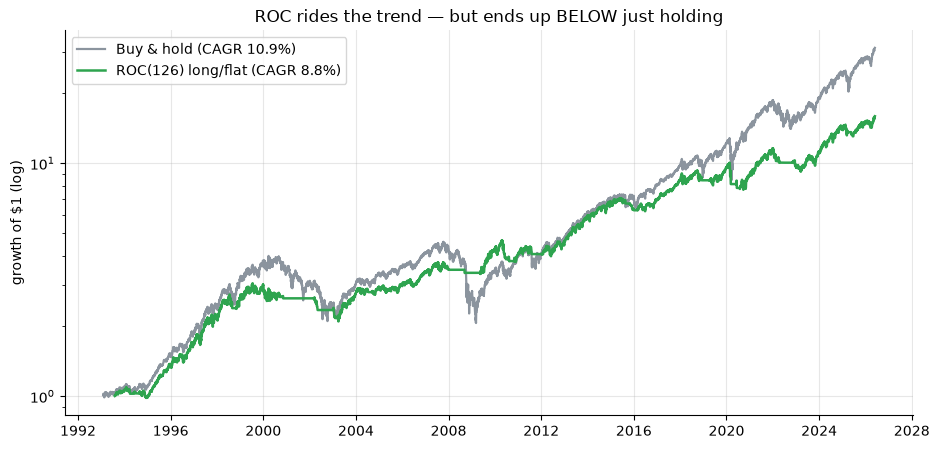

ROC  CAGR 8.8%  Sharpe 0.59  maxDD -31%
Hold CAGR 10.9%  Sharpe 0.54  maxDD -55%


In [2]:
if HAVE_REAL:
    bh = st.buy_and_hold(CLOSE)
    rb = st.book_returns(CLOSE, st.roc_signal(CLOSE, R['window'], 'long_flat'), R['cost_bps'])
    eq_bh = (1+bh['net']).cumprod(); eq_roc = (1+rb['net']).cumprod()
    fig, ax = plt.subplots(figsize=(9.5,4.6))
    ax.semilogy(eq_bh.index, eq_bh, color=GREY, lw=1.6, label=f"Buy & hold (CAGR {R['hold']['cagr']*100:.1f}%)")
    ax.semilogy(eq_roc.index, eq_roc, color=GREEN, lw=1.8, label=f"ROC({R['window']}) long/flat (CAGR {R['roc']['cagr']*100:.1f}%)")
    ax.set_ylabel('growth of $1 (log)'); ax.set_title('ROC rides the trend — but ends up BELOW just holding')
    ax.legend(); plt.tight_layout(); plt.show()
else:
    print('cache absent — see frozen numbers in R')
print(f"ROC  CAGR {R['roc']['cagr']*100:.1f}%  Sharpe {R['roc']['sharpe']:.2f}  maxDD {R['roc']['maxdd']*100:.0f}%")
print(f"Hold CAGR {R['hold']['cagr']*100:.1f}%  Sharpe {R['hold']['sharpe']:.2f}  maxDD {R['hold']['maxdd']*100:.0f}%")

The green line (ROC) spends the whole chart **below** the grey line (hold). ROC grows your dollar at **8.8%/yr** vs **10.9%/yr** for holding. It's not that ROC is *bad* — it's that being in cash part of the time means you miss some of the bull market you were trying to ride.

**So where's the upside?** The drawdown. Here's the worst peak-to-trough loss for each. This is the whole case for ROC.

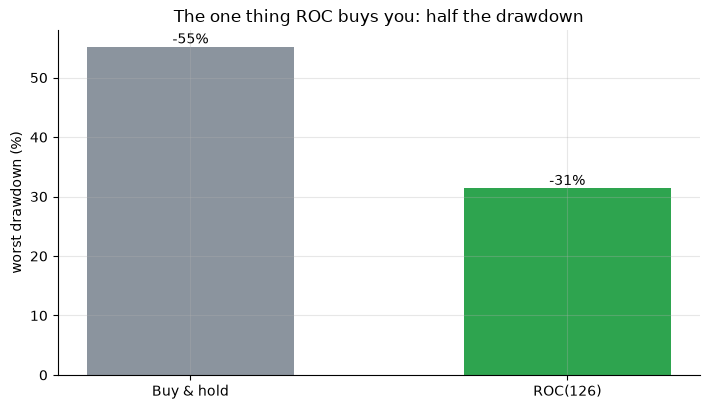

hold worst loss -55%  ->  ROC worst loss -31%


In [3]:
rules = ['Buy & hold', f"ROC({R['window']})"]
dd = [abs(R['hold']['maxdd'])*100, abs(R['roc']['maxdd'])*100]
fig, ax = plt.subplots(figsize=(7.2,4.2))
ax.bar(rules, dd, color=[GREY, GREEN], width=.55)
for i,v in enumerate(dd): ax.annotate(f'-{v:.0f}%',(i,v),ha='center',va='bottom')
ax.set_ylabel('worst drawdown (%)'); ax.set_title('The one thing ROC buys you: half the drawdown')
plt.tight_layout(); plt.show()
print(f"hold worst loss {R['hold']['maxdd']*100:.0f}%  ->  ROC worst loss {R['roc']['maxdd']*100:.0f}%")

There's the real benefit: ROC cuts the worst loss from **-55%** to **-31%** by stepping aside in 2008 and 2020. That's genuine risk management — but it's a *trade*, not a free lunch: you pay for the calm with ~2%/yr of return.

**Now the vanity check.** Is ROC a *better* momentum tool than the alternatives, or do they all do the same job? Here's the Sharpe of each rule on the same tape, same costs.

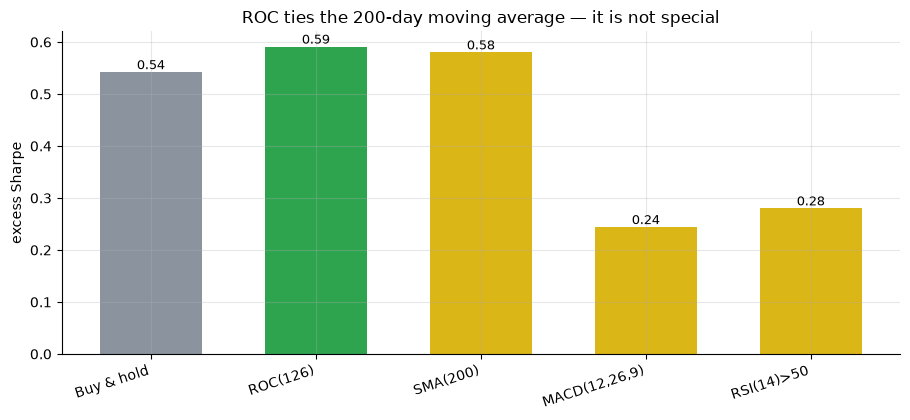

ROC(126) Sharpe 0.591  vs SMA(200) Sharpe 0.58


In [4]:
names = [r[0] for r in R['race']]; sh = [r[1] for r in R['race']]
cols = [GREY] + [GREEN if n.startswith('ROC') else AMBER for n in names[1:]]
fig, ax = plt.subplots(figsize=(9.2,4.3))
ax.bar(range(len(names)), sh, color=cols, width=.62)
for i,v in enumerate(sh): ax.annotate(f'{v:.2f}',(i,v),ha='center',va='bottom',fontsize=9)
ax.set_xticks(range(len(names))); ax.set_xticklabels(names, rotation=18, ha='right')
ax.set_ylabel('excess Sharpe'); ax.set_title('ROC ties the 200-day moving average — it is not special')
plt.tight_layout(); plt.show()
print('ROC(126) Sharpe', R['race'][1][1], ' vs SMA(200) Sharpe', R['race'][2][1])

This is the punchline. **ROC (0.59)** and a plain **200-day moving-average cross (0.58)** are a dead heat — and both beat the fussier MACD and RSI rules (which churn far more and earn less). The lesson isn't "ROC is great," it's "**any** simple trend filter does roughly the same thing, and the specific indicator is marketing."

## 5 · The verdict

- **Signal — Weak.** ROC's timing isn't random (the quants notebook shows it beats a shuffled schedule), but its edge **over buy-and-hold** is **−3.0%/yr** at *t* = −1.47 — i.e. *not* a positive, significant alpha. It's a beta-reducer dressed up as a signal.
- **Tradability — Mirage.** You can run it, but it **lowers** your return; the only thing it delivers is a smaller drawdown, which a 200-day SMA delivers identically. No incremental money to be made.
- **"Better momentum tool"? — Misattributed.** ROC ties the simplest moving average. The benefit people credit to ROC is just "stay long in uptrends" — shared by every trend rule.

## 6 · Could you actually trade it?

Costs aren't even the problem here — ROC trades rarely (about 7 turns a year), so it survives a wide range of cost assumptions. The problem is more basic: **there's no extra return to harvest.** Watch the net Sharpe barely move as costs climb.

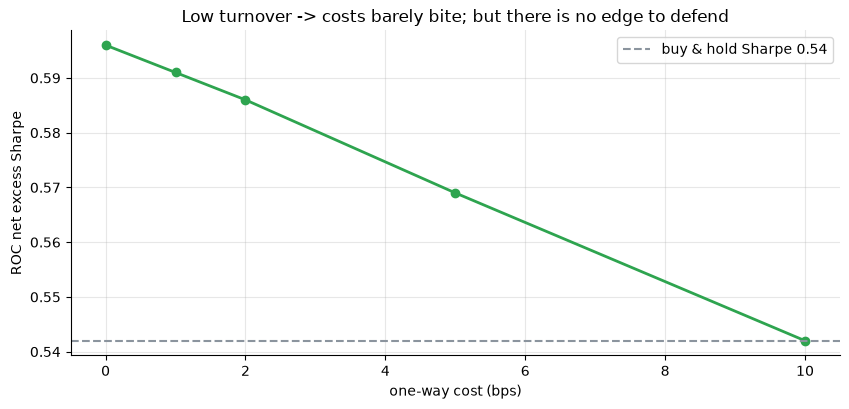

ROC Sharpe at 1bp 0.591  at 10bp 0.542


In [5]:
cb = [c[0] for c in R['costs']]; cs = [c[1] for c in R['costs']]
fig, ax = plt.subplots(figsize=(8.6,4.2))
ax.plot(cb, cs, 'o-', color=GREEN, lw=2)
ax.axhline(R['hold']['sharpe'], ls='--', color=GREY, label=f"buy & hold Sharpe {R['hold']['sharpe']:.2f}")
ax.set_xlabel('one-way cost (bps)'); ax.set_ylabel('ROC net excess Sharpe')
ax.set_title('Low turnover -> costs barely bite; but there is no edge to defend'); ax.legend()
plt.tight_layout(); plt.show()
print('ROC Sharpe at 1bp', R['costs'][1][1], ' at 10bp', R['costs'][4][1])

ROC's Sharpe edges buy-and-hold's even at 10 bps — but remember *why*: it carries less risk, not more return. If you want the lower drawdown, ROC (or an SMA) gives it to you cheaply. If you want **more money**, neither does. That's the candid bottom line: a fine risk dial, a non-existent alpha.

## 7 · Going further 🚪

- **Tune the lookback.** Shorter ROC windows (21, 63 days) trail *more* (they whipsaw); longer ones (252) close the gap to holding by just... holding more. There's no magic N.
- **Long/short is worse.** Flipping to short when ROC < 0 *halves* the Sharpe — shorting a market with a long-run upward drift is a losing add-on.
- **The real use.** Treat ROC as a **risk overlay** (cap your drawdown), not a return engine. And if you do, use whichever trend filter you find clearest — they're interchangeable.

*Think a specific ROC window beats buy-and-hold's CAGR after costs? Show the **delta vs hold** landing positive with t ≥ 2 — then we'll talk.*